# Hierarchical Clustering

In [1]:
# Import datasets from sklearn / Импорт наборов данных из sklearn
from sklearn.datasets import fetch_20newsgroups

# Hierarchical clustering imports / Импорт для иерархической кластеризации
from scipy.cluster.hierarchy import ward, dendrogram

# Matplotlib for plotting / Matplotlib для построения графиков
import matplotlib as mpl

# Functions for cluster extraction / Функции для извлечения кластеров
from scipy.cluster.hierarchy import fcluster

# Cosine similarity metric / Метрика косинусного сходства
from sklearn.metrics.pairwise import cosine_similarity

# Data manipulation / Работа с данными
import pandas as pd
import numpy as np

# Plotting library / Библиотека для визуализации
import matplotlib.pyplot as plt

# Jupyter magic for inline plots / Магия Jupyter для встроенных графиков
%matplotlib inline

# Regular expressions for text cleaning / Регулярные выражения для очистки текста
import re
import string

# NLP libraries for text preprocessing / NLP библиотеки для предобработки текста
from nltk import word_tokenize  # Tokenization / Токенизация
from nltk.corpus import stopwords  # Stop words removal / Удаление стоп-слов
from nltk.stem import WordNetLemmatizer  # Lemmatization / Лемматизация

# Text vectorization / Векторизация текста
from sklearn.feature_extraction.text import TfidfVectorizer

# Counter for frequency analysis / Счетчик для частотного анализа
from collections import Counter

# Plot customization / Настройка графиков
from pylab import *

# Main NLTK library / Основная библиотека NLTK
import nltk

# Suppress warning messages / Подавление предупреждений
import warnings
warnings.filterwarnings('ignore')

In [2]:
# Download required NLTK resources / Загрузка необходимых ресурсов NLTK
nltk.download('punkt_tab')      # For word_tokenize / Для токенизации
nltk.download('punkt')           # Additional tokenizer data / Дополнительные данные токенизатора
nltk.download('stopwords')       # For stop words / Для стоп-слов
nltk.download('wordnet')         # For lemmatizer / Для лемматизатора

[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\Admin\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\Admin\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Admin\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\Admin\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

In [3]:
stop_words = stopwords.words('english')

#adding individual printable characters to list of wtop words so that they get renoved along with the stopwords
stop_words = stop_words + list(string.printable)

print(stop_words[:10])

['a', 'about', 'above', 'after', 'again', 'against', 'ain', 'all', 'am', 'an']


In [4]:
lemmatizer = WordNetLemmatizer()

## All 20 Categories in `fetch_20newsgroups`
You can choose categories at your discretion.
| # | Category Name | Description |
|---|----------------|-------------|
| 1 | `alt.atheism` | Discussions about atheism and related topics |
| 2 | `comp.graphics` | Computer graphics, algorithms, and software |
| 3 | `comp.os.ms-windows.misc` | Microsoft Windows operating system discussions |
| 4 | `comp.sys.ibm.pc.hardware` | IBM PC compatible hardware |
| 5 | `comp.sys.mac.hardware` | Apple Macintosh hardware |
| 6 | `comp.windows.x` | X Window System discussions |
| 7 | `misc.forsale` | Items for sale or wanted |
| 8 | `rec.autos` | Automobiles and automotive topics |
| 9 | `rec.motorcycles` | Motorcycles and riding |
| 10 | `rec.sport.baseball` | Baseball discussions |
| 11 | `rec.sport.hockey` | Hockey discussions |
| 12 | `sci.crypt` | Cryptography and related topics |
| 13 | `sci.electronics` | Electronics and circuit design |
| 14 | `sci.med` | Medicine and health-related discussions |
| 15 | `sci.space` | Space exploration and astronomy |
| 16 | `soc.religion.christian` | Christianity and religious discussions |
| 17 | `talk.politics.guns` | Gun control and firearms politics |
| 18 | `talk.politics.mideast` | Middle Eastern politics |
| 19 | `talk.politics.misc` | Miscellaneous political discussions |
| 20 | `talk.religion.misc` | Miscellaneous religious discussions |

It will be a big plus if you choose a different dataset: 
[Scikit-learn Datasets Documentation](https://scikit-learn.org/stable/api/sklearn.datasets.html)

In [5]:
# This may take some time
categories= ['misc.forsale', 'sci.electronics', 'talk.religion.misc']
news_data = fetch_20newsgroups(subset='train', categories=categories,\
                               shuffle=True, random_state=42, download_if_missing=True)

## Main Parameters of `fetch_20newsgroups()`

| Parameter | Type | Default | Description |
|-----------|------|---------|-------------|
| `subset` | str or `None` | `'train'` | Which subset to load. Options: `'train'`, `'test'`, `'all'` |
| `categories` | list or `None` | `None` | List of category names to load. `None` loads all 20 categories |
| `shuffle` | bool | `False` | Whether to shuffle the data. Useful for model training |
| `random_state` | int or `None` | `None` | Seed for reproducible shuffling. Only used if `shuffle=True` |
| `download_if_missing` | bool | `True` | Automatically download the dataset if not found locally |
| `remove` | tuple or `None` | `None` | Remove parts of the text. Options: `('headers', 'footers', 'quotes')` |
| `data_home` | str or `None` | `None` | Directory to cache the dataset. Default is `~/scikit_learn_data` |
| `return_X_y` | bool | `False` | If `True`, returns `(data, target)` tuple instead of a Bunch object |

## Data Exploration

In [6]:
news_data.keys()

dict_keys(['data', 'filenames', 'target_names', 'target', 'DESCR'])

In [7]:
news_data['target_names']

['misc.forsale', 'sci.electronics', 'talk.religion.misc']

In [8]:
news_data['target'][:5]

array([0, 0, 1, 1, 0])

In [9]:
news_data['data'][:2]

['From: Steve@Busop.cit.wayne.edu (Steve Teolis)\nSubject: Re: *** TurboGrafx System For SALE ***\nOrganization: Wayne State University\nLines: 38\nDistribution: na\nNNTP-Posting-Host: 141.217.75.24\n\n>TurboGrafx-16 Base Unit (works like new) with:\n>       1 Controller\n>       AC Adapter\n>       Antenna hookup\n>     * Games:\n>         Kieth Courage\n>         Victory Run\n>         Fantasy Zone\n>         Military Madness\n>         Battle Royal\n>         Legendary Axe\n>         Blazing Lasers\n>         Bloody Wolf\n>\n>  --------------------------------------\n>* Will sell games separatley at $25 each\n>  --------------------------------------\n\nYour kidding, $210.00, man o man, you can buy the system new for $49.00 at \nElectronic Boutique and those games are only about $15 - $20.00 brand new.  \nMaybe you should think about that price again if you REALLY need the money.\n\n\n\n\n\n\n                        \n                        \n                        -=-=-=-=-=-=-=-

In [10]:
news_data.target # `news_data.target` and `news_data['target']` are the same thing.

array([0, 0, 1, ..., 0, 1, 0])

In [11]:
Counter(news_data.target)

Counter({np.int64(1): 591, np.int64(0): 585, np.int64(2): 377})

In [12]:
news_data.target_names

['misc.forsale', 'sci.electronics', 'talk.religion.misc']

In [13]:
news_data_df = pd.DataFrame({'text' : news_data['data'], 'category': news_data.target})
news_data_df.head()

,text,category
0,From: Steve@Busop.cit.wayne.edu (Steve Teolis)...,0
1,From: jks2x@holmes.acc.Virginia.EDU (Jason K. ...,0
2,From: wayne@uva386.schools.virginia.edu (Tony ...,1
3,From: lihan@ccwf.cc.utexas.edu (Bruce G. Bostw...,1
4,From: myoakam@cis.ohio-state.edu (micah r yoak...,0


In [14]:
news_data_df['category'].value_counts()

category
1    591
0    585
2    377
Name: count, dtype: int64

In [15]:
# Clean text: remove punctuation → tokenize → lowercase → remove stopwords → lemmatize
# Очистка текста: удалить пунктуацию → токенизировать → нижний регистр → удалить стоп-слова → лемматизировать
news_data_df['cleaned_text'] = news_data_df['text'].apply(\
lambda x : ' '.join([lemmatizer.lemmatize(word.lower()) \
    for word in word_tokenize(re.sub(r'([^\s\w]|_)+', ' ', str(x))) if word.lower() not in stop_words]))

# You can also apply other approaches to processing

In [16]:
news_data_df.shape

(1553, 3)

In [17]:
# Create TF-IDF model: converts text to numerical feature vectors
# TF-IDF = Term Frequency - Inverse Document Frequency (weights rare words higher)
# Создание TF-IDF модели: преобразует текст в числовые векторы признаков
# TF-IDF = Частота термина - обратная частота документа (редкие слова получают больший вес)
tfidf_model = TfidfVectorizer(max_features=400) # more features = more information but slower

# Fit model to cleaned text and transform to dense matrix, then create DataFrame
# Обучение модели на очищенном тексте и преобразование в плотную матрицу, создание DataFrame
tfidf_df = pd.DataFrame(tfidf_model.fit_transform(news_data_df['cleaned_text']).todense())

# Set column names as sorted vocabulary words (feature names)
# Установка названий столбцов как отсортированных слов словаря (названия признаков)
tfidf_df.columns = sorted(tfidf_model.vocabulary_)

# Display first 5 rows of the TF-IDF matrix
# Показать первые 5 строк TF-IDF матрицы
tfidf_df.head()

,00,10,100,11,12,13,14,15,16,17,...,without,word,work,world,would,writes,wrong,wrote,year,yes
0,0.413715,0.0,0.000000,0.000000,0.0,0.0,0.000000,0.121340,0.129921,0.0,...,0.0,0.0,0.107349,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0
1,0.000000,0.0,0.000000,0.212947,0.0,0.0,0.000000,0.180465,0.000000,0.0,...,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0
2,0.000000,0.0,0.000000,0.000000,0.0,0.0,0.000000,0.000000,0.000000,0.0,...,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0
3,0.000000,0.0,0.000000,0.000000,0.0,0.0,0.000000,0.000000,0.000000,0.0,...,0.0,0.0,0.000000,0.117367,0.087709,0.082751,0.0,0.0,0.0,0.0
4,0.000000,0.0,0.152513,0.000000,0.0,0.0,0.141384,0.134194,0.000000,0.0,...,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0


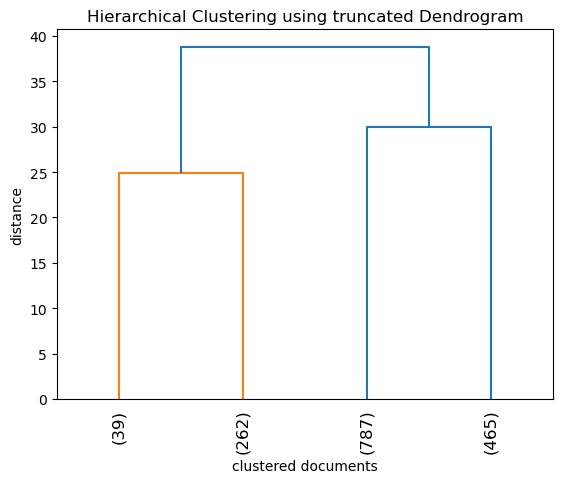

In [25]:
# Convert similarity to distance: distance = 1 - similarity
# Преобразование сходства в расстояние: расстояние = 1 - сходство
dist = 1 - cosine_similarity(tfidf_df)

# Perform Ward's hierarchical clustering (minimizes variance within clusters)
# Выполнение иерархической кластеризации методом Уорда (минимизирует дисперсию внутри кластеров)
linkage_matrix = ward(dist) 

# Truncating the Dendrogram to show last 4 clusters
# Усечение дендрограммы для отображения последних 4 кластеров
plt.title('Hierarchical Clustering using truncated Dendrogram')
plt.xlabel('clustered documents')  # Кластеризованные документы
plt.ylabel('distance')  # Расстояние

dendrogram(
    linkage_matrix,
    truncate_mode='lastp',  # showing only last p clusters after merging / показываем только последние p кластеров
    p=4,  # number of clusters to display / количество отображаемых кластеров
    leaf_rotation=90.,  # rotate leaf labels 90 degrees / поворот меток листьев на 90 градусов
    leaf_font_size=12.  # font size for leaf labels / размер шрифта для меток листьев
)
plt.show()

In [19]:
#Let's create 4 cluster from the linkage matrix
k=4
clusters = fcluster(linkage_matrix, k, criterion='maxclust')
clusters

array([4, 3, 3, ..., 3, 3, 4], dtype=int32)

In [20]:
news_data_df['obtained_clusters'] = clusters

In [23]:
categories

['misc.forsale', 'sci.electronics', 'talk.religion.misc']

In [24]:
#Let's validate the cluster we have created with the actual categories
pd.crosstab(news_data_df['category'].replace({0:categories[0], 1:categories[1], 2:categories[2]}),\
            news_data_df['obtained_clusters'].\
            replace({1 : 'cluster_1', 2 : 'cluster_2', 3 : 'cluster_3', 4: 'cluster_4'}))


obtained_clusters,cluster_1,cluster_2,cluster_3,cluster_4
category,,,,
misc.forsale,0,3,237,345
sci.electronics,0,11,496,84
talk.religion.misc,39,248,54,36
